In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('unsupervised_data.csv')

# Inspect the data
print(df.head())
print(df.info())
print(df.describe())

   ID  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6
0   1 -21.904591 -22.659091  12.805995 -46.631935 -34.347081 -21.989738
1   2 -28.662385  68.757081  31.761821   3.982259 -62.876866 -61.838563
2   3 -62.551204  60.909235   8.112918  24.110050 -64.372336  70.681940
3   4  14.428024 -48.326045 -65.576518  76.027549  69.966852  48.023953
4   5   9.780285 -55.643172 -72.737299  74.180123  67.873327  41.128015
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         40000 non-null  int64  
 1   Feature_1  40000 non-null  float64
 2   Feature_2  40000 non-null  float64
 3   Feature_3  40000 non-null  float64
 4   Feature_4  40000 non-null  float64
 5   Feature_5  40000 non-null  float64
 6   Feature_6  40000 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.1 MB
None
                ID     Feature_1     Feature_

Inertias: [np.float64(474281050.9758847), np.float64(331140032.62952006), np.float64(245993205.61897796), np.float64(153193732.05485684), np.float64(60602285.04862427), np.float64(24979353.351743333), np.float64(79997575.17278586), np.float64(11569342.081552383), np.float64(11375885.157397823), np.float64(24365972.44432213)]


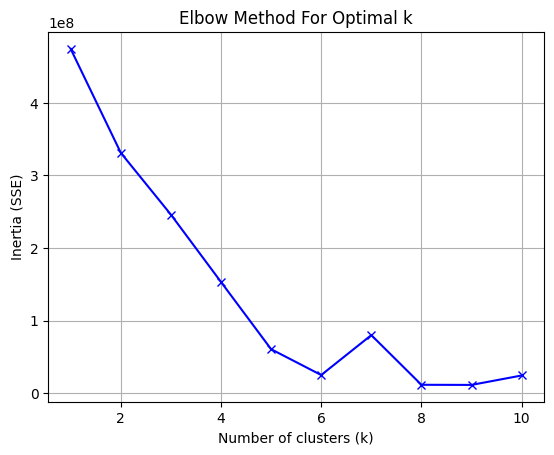

In [2]:

import pandas as pd
import matplotlib.pyplot as plt

class KMeansClustering:
    def __init__(self):
        self.x = None
        self.idx = None
        self.centroids = None
        self.k = None
        self.epochs_limit = None
        self.epochs_count = None

    def find_nearest_clusters(self):

        distances = np.linalg.norm(self.x[:, np.newaxis] - self.centroids, axis=2)
        self.idx = np.argmin(distances, axis=1)

    def compute_centroids(self):
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.k):
            points_in_cluster = self.x[self.idx == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = np.mean(points_in_cluster, axis=0)
            else:
                new_centroids[i] = self.x[np.random.choice(self.x.shape[0])]
        self.centroids = new_centroids

    def fit(self, x, k, epochs=50):
        self.x = x
        self.k = k
        self.epochs_limit = epochs
        self.epochs_count = 1

        indices = np.random.choice(self.x.shape[0], self.k, replace=False)
        self.centroids = self.x[indices].copy().astype(float)

        for _ in range(epochs):
            old_centroids = self.centroids.copy()
            self.find_nearest_clusters()
            self.compute_centroids()
            if np.allclose(old_centroids, self.centroids):
                break
            self.epochs_count += 1

    def calculate_inertia(self):
        inertia = 0
        for i in range(self.k):
            points = self.x[self.idx == i]
            if len(points) > 0:
                inertia += np.sum((points - self.centroids[i])**2)
        return inertia

# Load data
df = pd.read_csv('unsupervised_data.csv')
X = df.drop(columns=['ID']).values

# Elbow Method
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeansClustering()
    kmeans.fit(X, k=k, epochs=30)
    inertias.append(kmeans.calculate_inertia())

# Plotting the elbow curve
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.savefig('elbow_plot.png')

print("Inertias:", inertias)

Inertias (Smoothed): [np.float64(474281050.9758847), np.float64(327748660.18957305), np.float64(197012458.0026365), np.float64(170368184.4806634), np.float64(60602285.04862427), np.float64(102000698.49197206), np.float64(24795209.440287817), np.float64(11568064.953530215), np.float64(11375342.853178294), np.float64(11201113.78864362)]


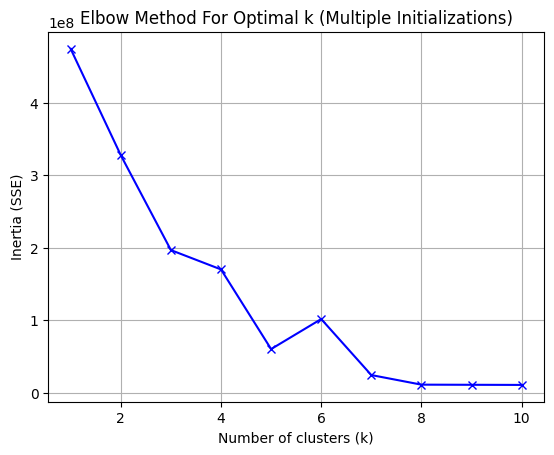

In [3]:
def run_kmeans_best(X, k, n_init=5, epochs=50):
    best_inertia = float('inf')
    best_model = None
    for _ in range(n_init):
        km = KMeansClustering()
        km.fit(X, k=k, epochs=epochs)
        inertia = km.calculate_inertia()
        if inertia < best_inertia:
            best_inertia = inertia
            best_model = km
    return best_inertia, best_model

inertias_v2 = []
k_range = range(1, 11)

for k in k_range:
    inertia, _ = run_kmeans_best(X, k, n_init=3, epochs=30)
    inertias_v2.append(inertia)

# Re-plot
plt.clf()
plt.plot(k_range, inertias_v2, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k (Multiple Initializations)')
plt.grid(True)
plt.savefig('elbow_plot_v2.png')

print("Inertias (Smoothed):", inertias_v2)

In [4]:
import numpy as np
import pandas as pd

class KMeansClustering:
    def __init__(self):
        self.x = None
        self.idx = None
        self.centroids = None
        self.k = None
        self.epochs_limit = None
        self.epochs_count = None

    def find_nearest_clusters(self):
        distances = np.linalg.norm(self.x[:, np.newaxis] - self.centroids, axis=2)
        self.idx = np.argmin(distances, axis=1)

    def compute_centroids(self):
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.k):
            points_in_cluster = self.x[self.idx == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = np.mean(points_in_cluster, axis=0)
            else:
                new_centroids[i] = self.x[np.random.choice(self.x.shape[0])]
        self.centroids = new_centroids

    def fit(self, x, k, epochs=50):
        self.x = x
        self.k = k
        self.epochs_limit = epochs
        self.epochs_count = 1

        indices = np.random.choice(self.x.shape[0], self.k, replace=False)
        self.centroids = self.x[indices].copy().astype(float)

        for _ in range(epochs):
            old_centroids = self.centroids.copy()
            self.find_nearest_clusters()
            self.compute_centroids()

            if np.allclose(old_centroids, self.centroids):
                break
            self.epochs_count += 1

    def calculate_inertia(self):
        inertia = 0
        for i in range(self.k):
            points = self.x[self.idx == i]
            if len(points) > 0:
                inertia += np.sum((points - self.centroids[i])**2)
        return inertia

df = pd.read_csv('unsupervised_data.csv')
X = df.drop(columns=['ID']).values

optimal_k = 8
model = KMeansClustering()
model.fit(X, k=optimal_k, epochs=100)

df['Cluster_Label'] = model.idx
df.to_csv('clustered_data_results.csv', index=False)